# Assignment 3: Implementing and Analyzing TD Algorithms
**Due:** Tuesday June 2, before midnight

**Objective:** To gain hands-on experience in implementing SARSA and Q-learning algorithms in gridworld.

**Tasks:**
- Implement SARSA algorithm: (10 points)
- Implement Q-learning algorithm: (10 points)
- Analyze SARSA and Q-learning algorithms. (40 points)
    1. Plot the average reward as a function of the number of steps (both algorithms)
    2. Generate the above plot for different values of epsilon (epsilon = 0.1, 0.5, 1) (both algorithms).
    3. How different values of epsilon affect the training in both algorithms? (both algorithms)
    4. What is the optimal value for epsilon? (both algorithms)

**Submission:**
- Python Code: Fully documented code implementing the algorithms. (60 points)
- Report: A comprehensive report detailing the algorithm's results, and an analysis describing task III. (40 points)

**The Problem Description:**
- States: the different position on the grid. S indicates the start state and G indicates the final state.
- Actions: up (0), right (1), down (2), and left (3).
- Rewards: -5 for bumping into a wall, +10 for reaching the goal, and 0 otherwise.
- Discount factor: γ = 0.9
- Note: You are given a code snippet. Feel free to use it or use your own implementation.

---

# Reinforcement Learning:Assignment 3

## Grid World Environement

The environement is a grid where the agent can go from one case to the next.

**Description**:
- **States:** the different position on the grid. `S` indicates the start state and `G` indicates the final state.
- **Actions:** up (`0`), right (`1`), down (`2`), and left (`3`).
- **Rewards:** `-5` for bumping into a wall, `+10` for reaching the goal, and `0` otherwise.
- **Discount factor:** $\gamma = 0.9$

We will use the environement called: `Grid`

imports from source modules

In [35]:
import sys
sys.path.append('..')

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import os

from src.config.config import settings, FIGURES_DIR
from src.utils.environment import Grid, Action, run_experiment
from src.utils.sarsa_agent import SarsaAgent
from src.utils.q_learning_agent import QLearningAgent
from src.utils.rewards import run_epsilon_comparison, plot_epsilon_comparison, plot_sarsa_vs_qlearning, smooth
from src.utils.visualizations import plot_values, plot_state_value, plot_action_values, visualise_policy, map_from_action_to_subplot


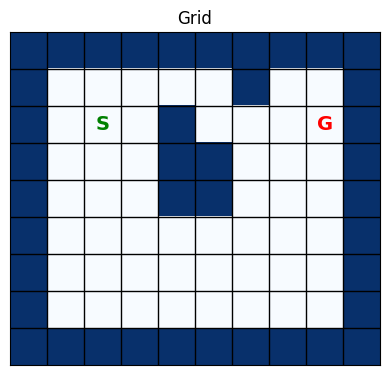

Grid plot saved to /mnt/c/cisc-856-assignment-3/docs/02-results/grid_plot.png


In [37]:
grid = Grid()
fig = grid.plot_grid()
plt.tight_layout()
os.makedirs(FIGURES_DIR, exist_ok=True)
plt.savefig(os.path.join(FIGURES_DIR, 'grid_plot.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f"Grid plot saved to {os.path.join(FIGURES_DIR, 'grid_plot.png')}")

### Exercise I: Implementing the Sarsa algorithm

**Description of Sarsa Algorithm (On-policy control for estimating $Q \approx q^*$):**

**Algorithm parameters**: step size $\alpha \in (0, 1]$, small $\epsilon > 0$

- Initialize $Q(s,a)$ arbitrarily except that $Q(terminal,\cdot\;) = 0$

- Loop for each episode:

    - Initialize $S$

    - Choose $A$ from $S$ using policy derived from $Q$ (e.g., $\epsilon$-greedy)
  
    - Loop for each step of episode:

        1. Take action $A$, observe $R$, $S^\prime$
        2. Choose $A^\prime$ from $S^\prime$ using policy derived from $Q$ (e.g., $\epsilon$-greedy)
        3. $Q(S, A)  = Q(S, A) + \alpha * (R + \gamma Q(S^\prime, A^\prime) - Q(S, A))$
        4. $S = S^\prime$, $A = A^\prime$ until S is terminal

### Testing your solution

running sarsa (eps=0.1, 100k steps)...

In [38]:
grid = Grid()
sarsa_agent = SarsaAgent(
    number_of_states=grid._layout.size,
    actions=Action,
    initial_state=grid.get_obs(),
    step_size=settings.learning_rate
)

In [39]:
mean_r, _ = run_experiment(grid, sarsa_agent, settings.num_steps, settings.epsilon)
print(f"  sarsa mean reward: {mean_r:.4f}")

  sarsa mean reward: 0.6373


In [40]:
q = sarsa_agent.q_values.reshape(grid._layout.shape + (4,))


<Figure size 1000x900 with 0 Axes>

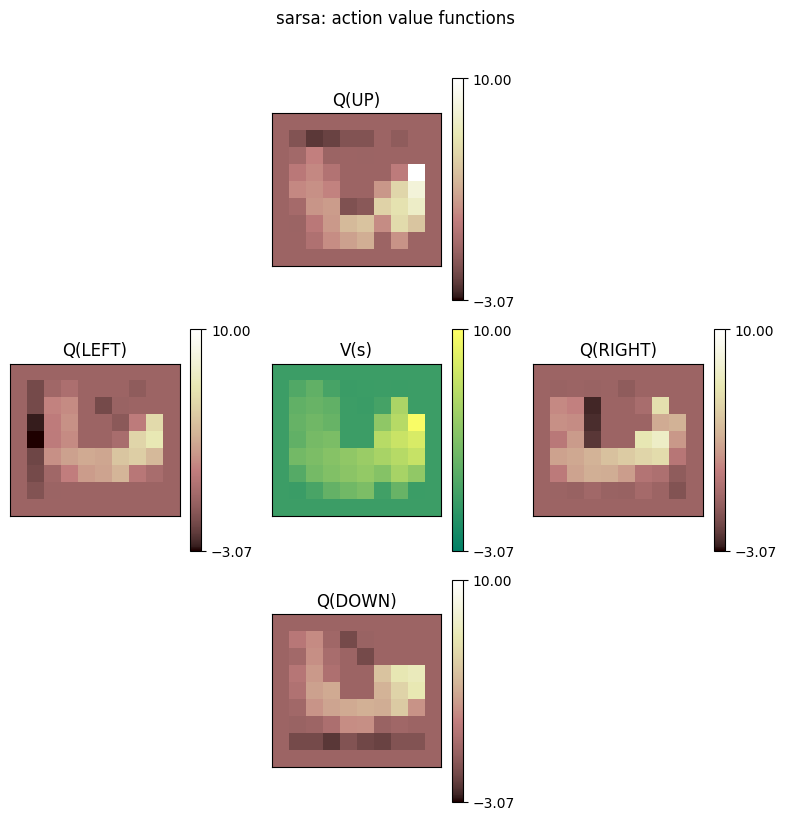

In [41]:
fig = plt.figure(figsize=(10, 9))
plot_action_values(q, epsilon=settings.epsilon)
plt.suptitle('sarsa: action value functions', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'sarsa_q_values.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

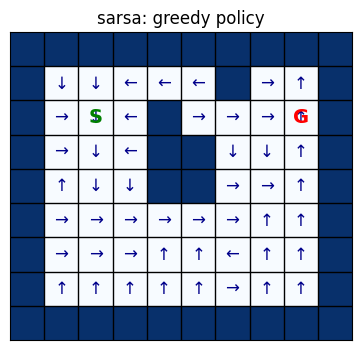

In [42]:
visualise_policy(grid, sarsa_agent)
plt.title('sarsa: greedy policy')
plt.savefig(os.path.join(FIGURES_DIR, 'sarsa_policy.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

### Exercise II: Implementing the Q-learning algorithm

**Description of Q-learning Algorithm (Off-policy control for estimating $Q \approx q^*$):**

**Algorithm parameters**: step size $\alpha \in (0, 1]$, small $\epsilon > 0$

- Initialize $Q(s,a)$ arbitrarily except that $Q(terminal,\cdot\;) = 0$

- Loop for each episode:

    - Initialize $S$
  
    - Loop for each step of episode:

        1. Choose $A$ from $S$ using policy derived from $Q$ (e.g., $\epsilon$-greedy)
        2. Take action $A$, observe $R$, $S^\prime$.
        3. $Q(S, A)  = Q(S, A) + \alpha * (R + \gamma \underset{a}{\rm max}Q(S^\prime, A^\prime) - Q(S, A))$
        4. $S = S^\prime$, $A = A^\prime$ until S is terminal

### Testing your solution

In [43]:
grid = Grid()


In [44]:
agent = QLearningAgent(
    number_of_states=grid._layout.size,
    actions=Action,
    initial_state=grid.get_obs(),
    step_size=settings.learning_rate
)

run_experiment(grid, agent, settings.num_steps, settings.epsilon)


(np.float64(0.9379500000000005),
 array([ 0.        , -2.5       , -1.66666667, ...,  0.93796876,
         0.93795938,  0.93795   ], shape=(100000,)))

AFTER 100000 STEPS ...


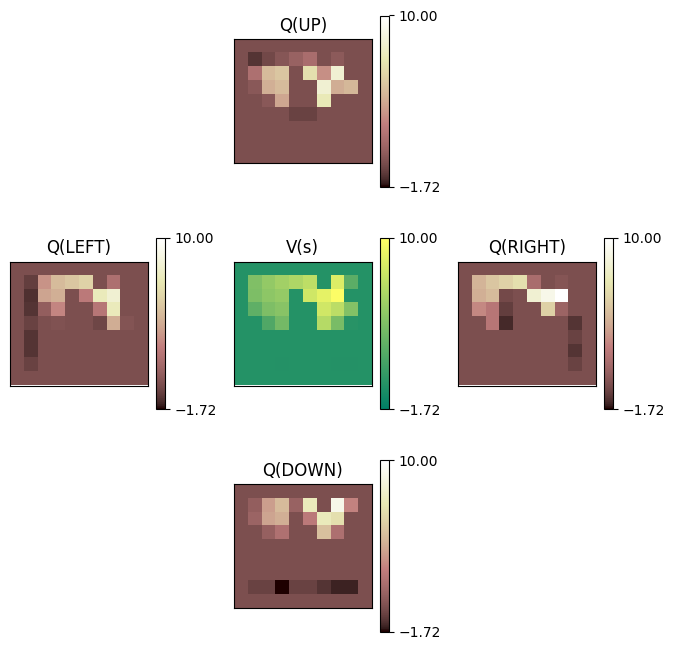

In [45]:
q = agent.q_values.reshape(grid._layout.shape + (4,))

print(f"AFTER {settings.num_steps} STEPS ...")
plot_action_values(q, epsilon=settings.epsilon)

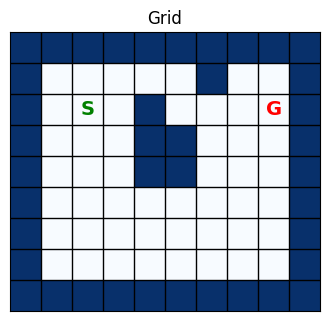

In [46]:
grid.plot_grid()

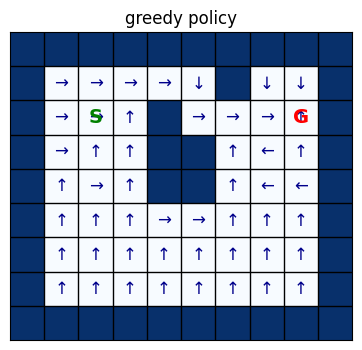

In [47]:
visualise_policy(grid, agent)


running q-learning (eps=0.1, 100k steps)...

In [48]:
print("running q-learning (eps=0.1, 100k steps)...")
grid        = Grid()
ql_agent    = QLearningAgent(
    number_of_states=grid._layout.size,
    actions=Action,
    initial_state=grid.get_obs(),
    step_size=settings.learning_rate
)
mean_r, _ = run_experiment(grid, ql_agent, settings.num_steps, settings.epsilon)
print(f"  q-learning mean reward: {mean_r:.4f}")


running q-learning (eps=0.1, 100k steps)...
  q-learning mean reward: 0.9384


<Figure size 1000x900 with 0 Axes>

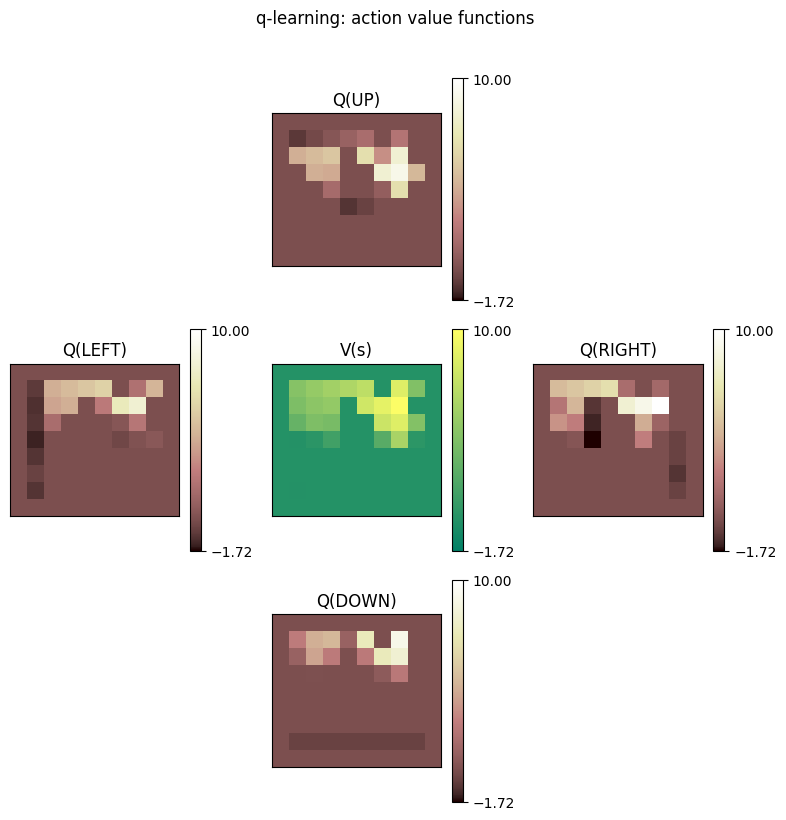

In [49]:
q = ql_agent.q_values.reshape(grid._layout.shape + (4,))
fig = plt.figure(figsize=(10, 9))
plot_action_values(q, epsilon=settings.epsilon)
plt.suptitle('q-learning: action value functions', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'qlearning_q_values.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

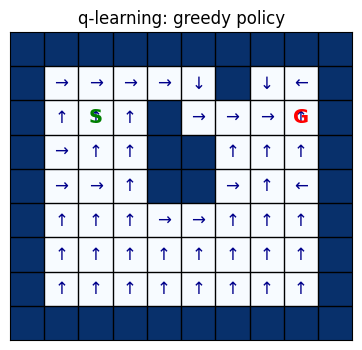

In [50]:
visualise_policy(grid, ql_agent)
plt.title('q-learning: greedy policy')
plt.savefig(os.path.join(FIGURES_DIR, 'qlearning_policy.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

### Exercise III. Analysis Tasks


#### Task 1: Plot the average reward as a function of the number of steps (both algorithms)

Plot the running mean reward over 100,000 steps for both SARSA and Q-learning at ε = 0.1.


In [51]:
print("running sarsa vs q-learning at eps=0.1 across 100k steps...")
grid = Grid()
sarsa_agent = SarsaAgent(
    number_of_states=grid._layout.size,
    actions=Action,
    initial_state=grid.get_obs(),
    step_size=settings.learning_rate
)
ql_agent = QLearningAgent(
    number_of_states=grid._layout.size,
    actions=Action,
    initial_state=grid.get_obs(),
    step_size=settings.learning_rate
)

running sarsa vs q-learning at eps=0.1 across 100k steps...


In [52]:
_, sarsa_hist = run_experiment(grid, sarsa_agent, settings.num_steps, settings.epsilon)
grid2 = Grid()
_, ql_hist   = run_experiment(grid2, ql_agent, settings.num_steps, settings.epsilon)


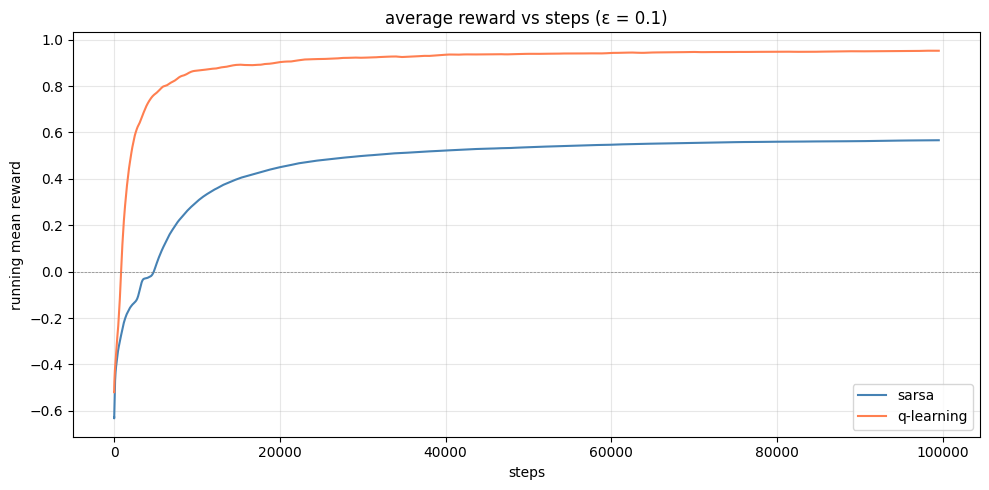

done.


In [53]:
fig, ax = plt.subplots(figsize=(10, 5))
window = 500
steps  = np.arange(len(smooth(sarsa_hist, window)))
ax.plot(steps, smooth(sarsa_hist, window), label='sarsa', color='steelblue')
ax.plot(steps, smooth(ql_hist,   window), label='q-learning', color='coral')
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.set_xlabel('steps')
ax.set_ylabel('running mean reward')
ax.set_title('average reward vs steps (\u03b5 = 0.1)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'task1_avg_reward.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("done.")

#### Task 2: Generate the above plot for different values of epsilon (epsilon = 0.1, 0.5, 1.0)



In [54]:
print(f"running epsilon sweep {settings.epsilons} x {settings.n_runs} seeds each...")
sarsa_results  = run_epsilon_comparison(SarsaAgent,     settings.num_steps, settings.n_runs, settings.epsilons)
qlearn_results = run_epsilon_comparison(QLearningAgent, settings.num_steps, settings.n_runs, settings.epsilons)


running epsilon sweep (0.1, 0.5, 1.0) x 5 seeds each...


In [55]:
plot_epsilon_comparison(sarsa_results, qlearn_results, settings.epsilons, settings.num_steps)
plot_sarsa_vs_qlearning(sarsa_results, qlearn_results, eps=0.1)
print("done")

saved: td_epsilon_comparison.png
saved: td_sarsa_vs_qlearning.png
done


#### Task 3: How different values of epsilon affect the training in both algorithms?


ε = 0.1 - just enough curiosity:
Both algorithms learn fast and settle at the highest average reward. The agent spends 90% of its time following what it knows, so it stops bumping into walls and reliably finds the goal. Q-learning edges slightly ahead in the long run, since it always chases the best possible next action (the max operator), it's aiming at the true optimal path even while exploring a bit. SARSA trails by a hair because it learns the value of its actual next action, which includes those occasional random moves.

ε = 0.5 - flipping a coin at every step
Half the actions are random. Convergence slows way down, and the agent racks up more -5 wall penalties. SARSA takes a bigger hit here, each update bakes in whatever random action happened next, so the noise seeps directly into the learned values. Q-learning's max operator shields it: even when the agent flails around, the update still tracks what the best action would have been.

ε = 1.0 - full chaos
No learning happens. The agent never exploits, it's pure random walk. Mean reward hovers near zero because it stumbles into the goal sometimes and into walls other times, with no pattern to remember. The Q-table ends up as random noise.

More exploration sounds helpful in theory, but in this gridworld it mostly means more wall penalties. SARSA feels the pain more because it learns the policy it's actually following (mistakes and all). Q-learning resists better since it always keeps one eye on the optimal path.

#### Task 4: What is the optimal value for epsilon?


ε = 0.1 - strikes the best balance for both algorithms. why:

That 10% random noise is enough for the agent to discover the goal early on, even when its Q-values start at zero and it has no clue where to go. But 90% of the time it's exploiting what it's learned, which keeps wall penalties low and cumulative reward high.

Why not lower (ε → 0)?

With zero exploration, an agent that starts with all-zero Q-values will pick the first action it checks (UP), every single time, and never learn anything else. It would be stuck in a local rut forever.

Why not higher?

Once the optimal path is found, extra exploration is just wasted steps. Every random move is a wall penalty you didn't need to take.

Q-learning can handle a bit more noise than SARSA, its off-policy update always looks at the best next action regardless of what the agent actually does, but for both algorithms, ε = 0.1 gives the cleanest trade-off between finding the goal and actually collecting reward.